CLASSIFICATION RESULTS
--------------------------------
Point (3,1) | Actual = +1 | Classifier 1 = 13.00 (+1) | Classifier 2 = 83.00 (+1)
Point (3,2) | Actual = +1 | Classifier 1 = 15.00 (+1) | Classifier 2 = 103.00 (+1)
Point (4,0) | Actual = +1 | Classifier 1 = 13.00 (+1) | Classifier 2 = 83.00 (+1)
Point (1,0) | Actual = -1 | Classifier 1 = 7.00 (+1) | Classifier 2 = 23.00 (+1)
Point (0,1) | Actual = -1 | Classifier 1 = 7.00 (+1) | Classifier 2 = 23.00 (+1)
Point (0,-1) | Actual = -1 | Classifier 1 = 3.00 (+1) | Classifier 2 = -17.00 (-1)

ERROR
--------------------------------
Classifier 1 misclassified points = 3
Classifier 1 error = 1.5

Classifier 2 misclassified points = 2
Classifier 2 error = 1.0


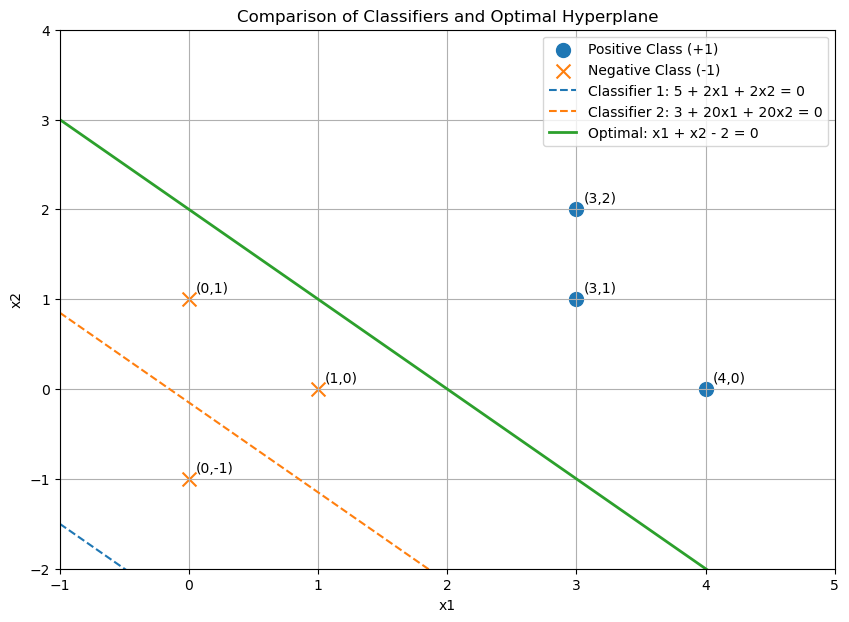

In [1]:
import numpy as np
import matplotlib.pyplot as plt

positive = np.array([
    [3, 1],
    [3, 2],
    [4, 0]
])

negative = np.array([
    [1, 0],
    [0, 1],
    [0, -1]
])

def classifier1(x1, x2):
    return 5 + 2*x1 + 2*x2

def classifier2(x1, x2):
    return 3 + 20*x1 + 20*x2

# x1 + x2 - 2 = 0
def optimal(x1, x2):
    return x1 + x2 - 2


def predict(value):
    if value >= 0:
        return 1
    else:
        return -1


print("CLASSIFICATION RESULTS")
print("--------------------------------")

true_labels = [1, 1, 1, -1, -1, -1]

points = np.vstack((positive, negative))

errors1 = 0
errors2 = 0

for i, point in enumerate(points):

    x1 = point[0]
    x2 = point[1]

    c1 = classifier1(x1, x2)
    c2 = classifier2(x1, x2)

    p1 = predict(c1)
    p2 = predict(c2)

    actual = true_labels[i]

    if p1 != actual:
        errors1 += 1

    if p2 != actual:
        errors2 += 1

    print(
        f"Point ({x1},{x2}) | "
        f"Actual = {actual:+d} | "
        f"Classifier 1 = {c1:.2f} ({p1:+d}) | "
        f"Classifier 2 = {c2:.2f} ({p2:+d})"
    )

E1 = 0.5 * errors1
E2 = 0.5 * errors2

print("\nERROR")
print("--------------------------------")
print("Classifier 1 misclassified points =", errors1)
print("Classifier 1 error =", E1)

print("\nClassifier 2 misclassified points =", errors2)
print("Classifier 2 error =", E2)


x = np.linspace(-1, 5, 500)

y1 = -(5 + 2*x) / 2
y2 = -(3 + 20*x) / 20
y_opt = 2 - x


plt.figure(figsize=(10, 7))
plt.scatter(
    positive[:, 0],
    positive[:, 1],
    marker='o',
    s=100,
    label='Positive Class (+1)'
)

plt.scatter(
    negative[:, 0],
    negative[:, 1],
    marker='x',
    s=100,
    label='Negative Class (-1)'
)

plt.plot(
    x,
    y1,
    '--',
    label='Classifier 1: 5 + 2x1 + 2x2 = 0'
)

plt.plot(
    x,
    y2,
    '--',
    label='Classifier 2: 3 + 20x1 + 20x2 = 0'
)

plt.plot(
    x,
    y_opt,
    linewidth=2,
    label='Optimal: x1 + x2 - 2 = 0'
)


for x1, x2 in positive:
    plt.annotate(
        f"({x1},{x2})",
        (x1, x2),
        xytext=(5, 5),
        textcoords="offset points"
    )

for x1, x2 in negative:
    plt.annotate(
        f"({x1},{x2})",
        (x1, x2),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Comparison of Classifiers and Optimal Hyperplane")

plt.xlim(-1, 5)
plt.ylim(-2, 4)

plt.grid(True)
plt.legend()

plt.show()